# 00 — Configuración, fuentes observacionales y trayectoria termodinámica

Este notebook prepara las carpetas de salida, define los datos observacionales que se usarán como comparación y construye las tablas de condiciones termodinámicas.

El objetivo es dejar ficheros CSV reutilizables por los notebooks de simulación y por la memoria en Typst.

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import scienceplots
    plt.style.use(["science", "grid"])
except Exception as exc:
    print("scienceplots no disponible, usando estilo por defecto:", exc)

BASE = Path.cwd()
FIG_DIR = BASE / "figures"
TAB_DIR = BASE / "tables"
DATA_DIR = BASE / "data"
GIF_DIR = BASE / "gifs"
for d in [FIG_DIR, TAB_DIR, DATA_DIR, GIF_DIR]:
    d.mkdir(exist_ok=True)

print("Base:", BASE)

Base: /home/daniel/GitHub/BNN_simulation/main


## Datos observacionales de referencia

No hay una “medida experimental de laboratorio” de las abundancias primordiales: se infieren de observaciones astrofísicas y de modelos de evolución química. Para comparar con una red BBN básica se usan normalmente:

- D/H en sistemas de absorción de cuásares de muy baja metalicidad.
- La fracción másica primordial de helio, $Y_p \simeq X(^4\mathrm{He})$, de regiones H II pobres en metales.
- El litio del plateau de Spite en estrellas pobres en metales.
- $^3\mathrm{He}/\mathrm{H}$, que es bastante menos limpio observacionalmente.

Estas cifras son valores de referencia razonables, no una compilación exhaustiva.

In [2]:
# Valores de referencia para comparación gráfica.
# value y sigma están en unidades lineales.
# Para Li se compara normalmente Li7/H observado con (Li7 + Be7)/H predicho,
# porque Be7 captura electrones y acaba contribuyendo a Li7 en épocas posteriores.

obs = pd.DataFrame([
    {
        "observable": "D/H",
        "quantity": "number_ratio",
        "value": 2.527e-5,
        "sigma": 0.030e-5,
        "model_column": "D/H",
        "source_key": "Cooke2018",
        "note": "Primordial deuterium from metal-poor quasar absorption systems."
    },
    {
        "observable": "Yp_He4",
        "quantity": "mass_fraction",
        "value": 0.2462,
        "sigma": 0.0022,
        "model_column": "X_He4",
        "source_key": "Aver2021",
        "note": "Primordial helium mass fraction from metal-poor HII regions."
    },
    {
        "observable": "He3/H",
        "quantity": "number_ratio",
        "value": 1.1e-5,
        "sigma": 0.2e-5,
        "model_column": "He3/H",
        "source_key": "Steigman2010",
        "note": "Poor primordial determination; Galactic HII values, mostly a consistency check."
    },
    {
        "observable": "Li7/H",
        "quantity": "number_ratio",
        "value": 1.6e-10,
        "sigma": 0.3e-10,
        "model_column": "Li7_plus_Be7_over_H",
        "source_key": "FieldsLithiumReview",
        "note": "Observed Spite plateau scale; compare to predicted Li7+Be7."
    },
])
obs.to_csv(DATA_DIR / "observational_abundances.csv", index=False)
obs

,observable,quantity,value,sigma,model_column,source_key,note
0,D/H,number_ratio,2.527000e-05,3.000000e-07,D/H,Cooke2018,Primordial deuterium from metal-poor quasar ab...
1,Yp_He4,mass_fraction,2.462000e-01,2.200000e-03,X_He4,Aver2021,Primordial helium mass fraction from metal-poo...
2,He3/H,number_ratio,1.100000e-05,2.000000e-06,He3/H,Steigman2010,Poor primordial determination; Galactic HII va...
3,Li7/H,number_ratio,1.600000e-10,3.000000e-11,Li7_plus_Be7_over_H,FieldsLithiumReview,Observed Spite plateau scale; compare to predi...


## Condiciones del enunciado y extrapolación a $t_0=10\,\mathrm{s}$

El trabajo pide los tres snapshots:

- $t\sim 50\,\mathrm{s}$, $T_9=1.7$, $\rho=2\times10^{-4}\,\mathrm{g\,cm^{-3}}$;
- $t\sim 200\,\mathrm{s}$, $T_9=1.0$, $\rho=2\times10^{-5}\,\mathrm{g\,cm^{-3}}$;
- $t\sim 1000\,\mathrm{s}$, $T_9=0.4$, $\rho=2\times10^{-6}\,\mathrm{g\,cm^{-3}}$.

Para poder arrancar también en $t_0=10\,\mathrm{s}$, se extrapola $T(t)$ y $\rho(t)$ en escala log-log a partir de los puntos del enunciado. Esto no sustituye a una evolución cosmológica completa: simplemente da una trayectoria suave y reproducible para alimentar la red nuclear.

In [3]:
# Snapshots del enunciado
snapshots = pd.DataFrame({
    "label": ["50 s", "200 s", "1000 s"],
    "t_s": [50.0, 200.0, 1000.0],
    "T9": [1.7, 1.0, 0.4],
    "rho_g_cm3": [2.0e-4, 2.0e-5, 2.0e-6],
})
snapshots["T_K"] = snapshots["T9"] * 1.0e9
snapshots.to_csv(DATA_DIR / "bbn_assignment_snapshots.csv", index=False)
snapshots

,label,t_s,T9,rho_g_cm3,T_K
0,50 s,50.0,1.7,0.000200,1.700000e+09
1,200 s,200.0,1.0,0.000020,1.000000e+09
2,1000 s,1000.0,0.4,0.000002,4.000000e+08


In [4]:
from scipy.interpolate import interp1d

_t_nodes = snapshots["t_s"].to_numpy(float)
_T9_nodes = snapshots["T9"].to_numpy(float)
_rho_nodes = snapshots["rho_g_cm3"].to_numpy(float)

_logT9 = interp1d(np.log(_t_nodes), np.log(_T9_nodes), fill_value="extrapolate")
_logrho = interp1d(np.log(_t_nodes), np.log(_rho_nodes), fill_value="extrapolate")

def T9_of_t(t):
    t = np.asarray(t, dtype=float)
    return np.exp(_logT9(np.log(t)))

def T_of_t(t):
    return 1.0e9 * T9_of_t(t)

def rho_of_t(t):
    t = np.asarray(t, dtype=float)
    return np.exp(_logrho(np.log(t)))

def n_gamma_cm3(T_K):
    # Número de fotones de un cuerpo negro: n_gamma = 2 zeta(3)/pi^2 * (kT/hbar c)^3.
    # En cgs puede escribirse de forma práctica como 20.28 T^3 cm^-3.
    return 20.28 * np.asarray(T_K, dtype=float)**3

def eta_of_t(t):
    # eta = n_b / n_gamma, con n_b ≈ rho / m_u.
    m_u = 1.66053906660e-24  # g
    nb = rho_of_t(t) / m_u
    return nb / n_gamma_cm3(T_of_t(t))

def radiation_T9_fit200(t):
    # Relación de orden de magnitud T9 ~ sqrt(200 s / t), normalizada para T9(200 s)=1.
    return np.sqrt(200.0 / np.asarray(t, dtype=float))

# Tabla termo para varios tiempos, incluyendo t0=10 s.
t_grid_table = np.array([10.0, 20.0, 50.0, 100.0, 200.0, 500.0, 1000.0, 3000.0, 1.0e4])
thermo = pd.DataFrame({
    "t_s": t_grid_table,
    "T9_assignment_interp": T9_of_t(t_grid_table),
    "T_K_assignment_interp": T_of_t(t_grid_table),
    "rho_g_cm3_assignment_interp": rho_of_t(t_grid_table),
    "eta": eta_of_t(t_grid_table),
    "eta10": 1.0e10 * eta_of_t(t_grid_table),
    "T9_radiation_fit_T9_200s_eq_1": radiation_T9_fit200(t_grid_table),
})
thermo.to_csv(DATA_DIR / "thermodynamic_history_reference.csv", index=False)
thermo

,t_s,T9_assignment_interp,T_K_assignment_interp,rho_g_cm3_assignment_interp,eta,eta10,T9_radiation_fit_T9_200s_eq_1
0,10.0,3.147689,3.147689e+09,2.897304e-03,2.758681e-09,27.586811,4.472136
1,20.0,2.414167,2.414167e+09,9.162079e-04,1.933637e-09,19.336367,3.162278
2,50.0,1.700000,1.700000e+09,2.000000e-04,1.208833e-09,12.088327,2.000000
3,100.0,1.303840,1.303840e+09,6.324555e-05,8.473046e-10,8.473046,1.414214
4,200.0,1.000000,1.000000e+09,2.000000e-05,5.938995e-10,5.938995,1.000000
5,500.0,0.593531,5.935310e+08,5.391462e-06,7.657010e-10,7.657010,0.632456
6,1000.0,0.400000,4.000000e+08,2.000000e-06,9.279679e-10,9.279679,0.447214
7,3000.0,0.214005,2.140049e+08,4.153592e-07,1.258449e-09,12.584493,0.258199
8,10000.0,0.107829,1.078292e+08,7.419138e-08,1.757222e-09,17.572224,0.141421


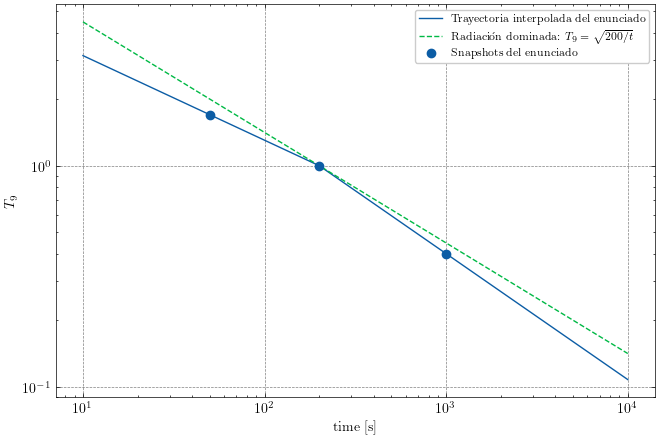

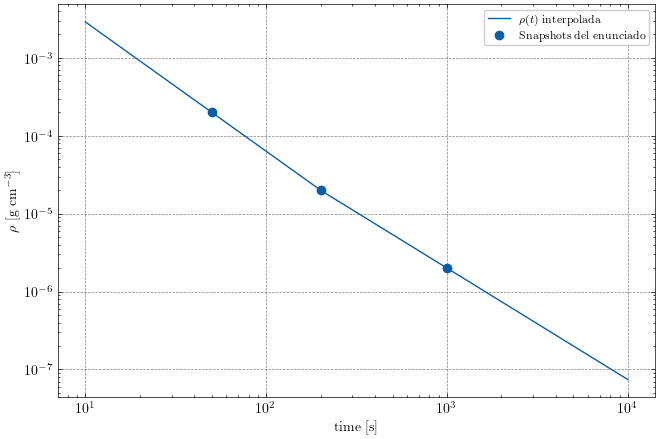

In [5]:
# Gráfica de la historia termodinámica que se usará en las simulaciones.
t_plot = np.geomspace(10.0, 1.0e4, 500)

fig, ax = plt.subplots(figsize=(6.8, 4.6))
ax.loglog(t_plot, T9_of_t(t_plot), label=r"Trayectoria interpolada del enunciado")
ax.loglog(t_plot, radiation_T9_fit200(t_plot), "--", label=r"Radiación dominada: $T_9=\sqrt{200/t}$")
ax.scatter(snapshots["t_s"], snapshots["T9"], marker="o", zorder=5, label="Snapshots del enunciado")
ax.set_xlabel("time [s]")
ax.set_ylabel(r"$T_9$")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_thermo_T9_models.pdf")
plt.show()

fig, ax = plt.subplots(figsize=(6.8, 4.6))
ax.loglog(t_plot, rho_of_t(t_plot), label=r"$\rho(t)$ interpolada")
ax.scatter(snapshots["t_s"], snapshots["rho_g_cm3"], marker="o", zorder=5, label="Snapshots del enunciado")
ax.set_xlabel("time [s]")
ax.set_ylabel(r"$\rho$ [g cm$^{-3}$]")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_thermo_rho_model.pdf")
plt.show()

## Referencias bibliográficas de los datos

El CSV de observaciones está pensado para comparación rápida. Para la memoria, cita las referencias originales y no solo este notebook.

In [6]:
references = pd.DataFrame([
    {"source_key": "Cooke2018", "reference": "Cooke, Pettini & Steidel, ApJ 855, 102 (2018)", "doi": "10.3847/1538-4357/aaab53"},
    {"source_key": "Aver2021", "reference": "Aver, Berg, Olive et al., JCAP 03, 027 (2021)", "doi": "10.1088/1475-7516/2021/03/027"},
    {"source_key": "Steigman2010", "reference": "Steigman, JCAP 04, 029 (2010)", "doi": "10.1088/1475-7516/2010/04/029"},
    {"source_key": "FieldsLithiumReview", "reference": "Fields, The Primordial Lithium Problem, ARNPS 61, 47 (2011)", "doi": "10.1146/annurev-nucl-102010-130445"},
    {"source_key": "Planck2018", "reference": "Planck Collaboration, A&A 641, A6 (2020)", "doi": "10.1051/0004-6361/201833910"},
])
references.to_csv(DATA_DIR / "references_observational_data.csv", index=False)
references

,source_key,reference,doi
0,Cooke2018,"Cooke, Pettini & Steidel, ApJ 855, 102 (2018)",10.3847/1538-4357/aaab53
1,Aver2021,"Aver, Berg, Olive et al., JCAP 03, 027 (2021)",10.1088/1475-7516/2021/03/027
2,Steigman2010,"Steigman, JCAP 04, 029 (2010)",10.1088/1475-7516/2010/04/029
3,FieldsLithiumReview,"Fields, The Primordial Lithium Problem, ARNPS ...",10.1146/annurev-nucl-102010-130445
4,Planck2018,"Planck Collaboration, A&A 641, A6 (2020)",10.1051/0004-6361/201833910
